# Topic analysis 

This notebook produces the analysis of the topics. 

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.cm as cm

import geopandas as gpd

from collections import Counter

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from umap import UMAP

from database.comments import Comments
from database.topics import Topics

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks

nlp_tasks = NLP_Tasks()
cs = Comments(env="dev")

Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


In [2]:
tp = Topics(env='dev')
tp_df = tp.read_all()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


In [3]:
tp_df

,id,comment_id,topic_number,probability,add_date
0,1,230384FUL_16,[],[],2025-10-21
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21
3,4,230384FUL_22,[47],[1.0],2025-10-21
4,5,230384FUL_15,[2],[1.0],2025-10-21
...,...,...,...,...,...
30325,30326,24/AP/2313_9,[37],[1.0],2025-10-21
30326,30327,241267FUL_81,[35],[1.0],2025-10-21
30327,30328,24/AP/2313_15,"[87, 44, 71, 72]","[0.13251934256196757, 0.0777459370777266, 0.07...",2025-10-21
30328,30329,24/AP/2313_17,"[25, 26]","[1.0, 0.7320134997496925]",2025-10-21


In [4]:
# bad_topics = {"bad":[0,11,27,32,38,51,57,89,98]}
# same_topics = {"parking":[1,16,28,31,41], 
#                "tree loss":[2,22,39], 
#                "out of character":[3,30], 
#                "too tall":[4,40],
#                "overdevelopment":[8,26,56],
#                "privacy":[10,35,42],
#                "public services":[12, 36],
#                "construction noise":[14,37,47]}

In [5]:
bad_topics = {"bad":[-1,0,10,16,31,39,41,42,56,57,88,98]}
same_topics = {"garden space":[1,43],
               "parking":[2,7,47], 
               "out of character":[3,36,40], 
               "too tall":[5,33],
               "conservation area":[8,35,48],
               "noise pollution":[11,38,46,49],
               "overdevelopment":[13,25],
               "traffic congestion":[18, 21]}

In [6]:
# Build a reverse mapping from each old topic → representative topic
topic_map = {}
for _, nums in same_topics.items():
    main = nums[0]
    for n in nums:
        topic_map[n] = main

tp_df['topic_number_updated'] = [[] for _ in range(len(tp_df))]
tp_df['probability_updated'] = [[] for _ in range(len(tp_df))]

for i in range(len(tp_df)):
    topics = tp_df.at[i, 'topic_number']
    probs = tp_df.at[i, 'probability']

    # filter out topics >= 50
    filtered = [(t, p) for t, p in zip(topics, probs) if t < 50]

    # filter out topics in bad_topics
    filtered = [(t, p) for t, p in filtered if all(t not in v for v in bad_topics.values())]

    # merge topics in same_topics
    merged = {}
    for t, p in filtered:
        new_t = topic_map.get(t, t)  # replace with main topic if part of a group
        merged[new_t] = merged.get(new_t, 0) + p  # sum probabilities

    # store results
    tp_df.at[i, 'topic_number_updated'] = list(merged.keys())
    tp_df.at[i, 'probability_updated'] = list(merged.values())

tp_df


,id,comment_id,topic_number,probability,add_date,topic_number_updated,probability_updated
0,1,230384FUL_16,[],[],2025-10-21,[],[]
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21,[2],[0.532771282582039]
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21,"[19, 13]","[0.7651527090417625, 0.1552818674969217]"
3,4,230384FUL_22,[47],[1.0],2025-10-21,[2],[1.0]
4,5,230384FUL_15,[2],[1.0],2025-10-21,[2],[1.0]
...,...,...,...,...,...,...,...
30325,30326,24/AP/2313_9,[37],[1.0],2025-10-21,[37],[1.0]
30326,30327,241267FUL_81,[35],[1.0],2025-10-21,[8],[1.0]
30327,30328,24/AP/2313_15,"[87, 44, 71, 72]","[0.13251934256196757, 0.0777459370777266, 0.07...",2025-10-21,[44],[0.0777459370777266]
30328,30329,24/AP/2313_17,"[25, 26]","[1.0, 0.7320134997496925]",2025-10-21,"[13, 26]","[1.0, 0.7320134997496925]"


In [7]:
topic_names = pd.read_csv('../outputs/topic_model/bertopic_less_topics/object_topics.csv')

In [8]:
topic_names.head(10)

,Topic,Count,Name,Representation,MaximalMarginalRelevance,KeyBERTInspired,Representative_Docs,doc_1,doc_2,doc_3
0,-1,38355,-1_the_to_and_of,"['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['parking', 'space', 'traffic', 'road', 'impac...",['i object to this proposal on several grounds...,i object to this proposal on several grounds. ...,"firstly, i have been very concerned by the beh...",residents of are already surrounded on two sid...
1,0,14746,0_object_planning_application_following,"['object', 'planning', 'application', 'followi...","['object', 'planning', 'application', 'followi...","['objection', 'following', 'reasons', 'applica...",['i strongly object to this proposal for the f...,i strongly object to this proposal for the fol...,i strongly object to this proposal for the fol...,i strongly object to this proposal for the fol...
2,1,7481,1_trees_garden_green_space,"['trees', 'garden', 'green', 'space', 'of', 't...","['trees', 'garden', 'green', 'space', 'of', 't...","['garden', 'trees', 'greenery', 'tree', 'natur...","['there is no space for a garden.', 'this deve...",there is no space for a garden.,this development is also contrary to the londo...,loss of garden / green space :
3,2,7004,2_parking_traffic_car_already,"['parking', 'traffic', 'car', 'already', 'tran...","['parking', 'traffic', 'car', 'already', 'tran...","['parking', 'car', 'traffic', 'bus', 'parked',...","['2. traffic and parking :', '4. parking', 'pa...",2. traffic and parking :,4. parking,parking :
4,3,6644,3_character_design_out_of,"['character', 'design', 'out', 'of', 'keeping'...","['character', 'design', 'out', 'of', 'keeping'...","['design', 'character', 'appearance', 'style',...","['out of keeping with character of area', 'the...",out of keeping with character of area,the proposal would be out of keeping with the ...,design and character
5,4,4212,4_light_sunlight_daylight_loss,"['light', 'sunlight', 'daylight', 'loss', 'wil...","['light', 'sunlight', 'daylight', 'loss', 'wil...","['light', 'sunlight', 'daylight', 'overshadow'...","['light', 'light :', '( c ) light ;']",light,light :,( c ) light ;
6,5,4029,5_height_scale_buildings_tall,"['height', 'scale', 'buildings', 'tall', 'of',...","['height', 'scale', 'buildings', 'tall', 'of',...","['height', 'tall', 'scale', 'overbearing', 'ma...","['height of the proposed buildings :', '- the ...",height of the proposed buildings :,- the height of the proposed development is no...,2. the development is not in keeping with the ...
7,6,3984,6_amenity_impact_on_of,"['amenity', 'impact', 'on', 'of', 'negative', ...","['amenity', 'impact', 'on', 'of', 'negative', ...","['amenity', 'impact', 'impacts', 'significant'...",['- impact on the residential amenity to neigh...,- impact on the residential amenity to neighbo...,* negative impact on the amenity of,impact on neighbouring amenity
8,7,3859,7_park_school_parking_car,"['park', 'school', 'parking', 'car', 'cars', '...","['park', 'school', 'parking', 'car', 'cars', '...","['park', 'gp', 'school', 'schools', 'parking',...",['there is only space for 6 cars in the car pa...,there is only space for 6 cars in the car park...,i object to this development due to the increa...,people from the high road already park over my...
9,8,3469,8_conservation_heritage_listed_area,"['conservation', 'heritage', 'listed', 'area',...","['conservation', 'heritage', 'listed', 'area',...","['conservation', 'heritage', 'listed', 'histor...","['conservation area', ""negative impact on the ...",conservation area,negative impact on the conservation area - dir...,conservation area :


In [9]:
# create dictionary mapping topic number to name
topic_dict = dict(zip(topic_names['Topic'], topic_names['Name']))

unique_topics = set()
for topics in tp_df['topic_number_updated']:
    unique_topics.update(topics)

filtered_topic_dict = {k: v for k, v in topic_dict.items() if k in unique_topics}

In [10]:
# remove number and underscores from topic names
for k in filtered_topic_dict:
    name = filtered_topic_dict[k]
    name = name.split('_', 1)[1] if '_' in name else name
    name = name.replace('_', ' ')
    filtered_topic_dict[k] = name

In [ ]:
custom_hex_colors = [
    "#1871b0", "#82d64b", "#fe9e29", "#cf4242", "#a373d0",
    "#865349", "#F2F527", "#494A2A", "#df51b4", "#7d6565", 
    "#1cc6d9", "#453D70", "#bcbd22", "#09A31B", "#91e0b0",
    "#a1c7e3", "#d1e7c3", "#e3d1bc", "#b48989", "#4e0f88",
    "#D12E0E", "#B4B489", "#EDEEE0", "#df9fcc", "#e58888", 
    "#a8dadf", "#7A6CC8", "#A7A70A", "#A1D6A7", "#27c968"
]

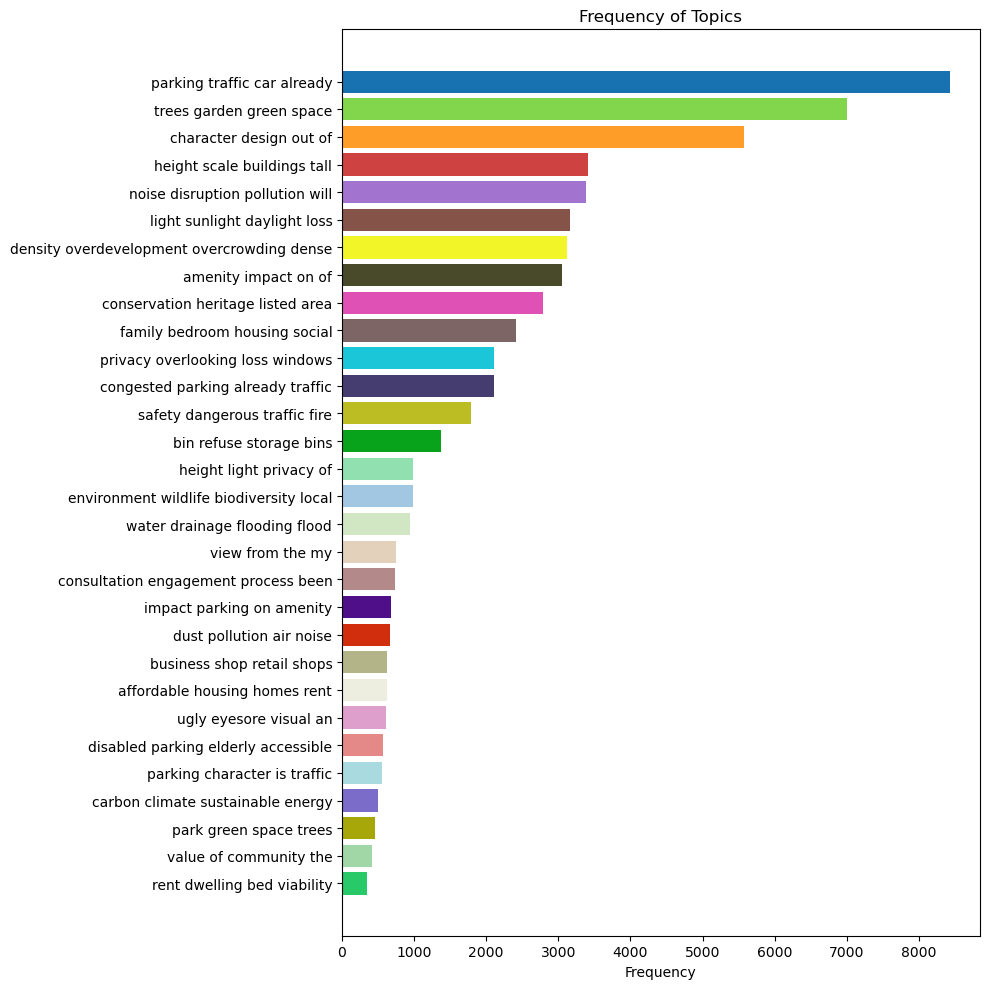

In [45]:
# Flatten topics
all_topics = [t for topics in tp_df['topic_number_updated'] for t in topics]

# Count frequencies
topic_counts = Counter(all_topics)

# Keep only topics with count > 0 and that exist in filtered_topic_dict
topic_counts = {k: v for k, v in topic_counts.items() if v > 0 and k in filtered_topic_dict}

# Sort by frequency (descending)
topic_counts = dict(sorted(topic_counts.items(), key=lambda x: x[1], reverse=True))

# Convert to parallel lists for plotting (categorical x-axis)
x_labels = [filtered_topic_dict[k] for k in topic_counts.keys()]
y_values = list(topic_counts.values())

# Plot horizontal bar chart
plt.figure(figsize=(10, 10))
plt.barh(x_labels, y_values, color=custom_hex_colors[:len(x_labels)])

# Invert y-axis so the most frequent is on top
plt.gca().invert_yaxis()

# Label axes and title
# plt.ylabel('Topic')
plt.xlabel('Frequency')
plt.title('Frequency of Topics')

plt.tight_layout()

plt.savefig('../figures/object_topics_frequency.png', dpi=500)
plt.show()


## Alternative approach to selecting topics 

In [12]:
tp_df

,id,comment_id,topic_number,probability,add_date,topic_number_updated,probability_updated
0,1,230384FUL_16,[],[],2025-10-21,[],[]
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21,[2],[0.532771282582039]
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21,"[19, 13]","[0.7651527090417625, 0.1552818674969217]"
3,4,230384FUL_22,[47],[1.0],2025-10-21,[2],[1.0]
4,5,230384FUL_15,[2],[1.0],2025-10-21,[2],[1.0]
...,...,...,...,...,...,...,...
30325,30326,24/AP/2313_9,[37],[1.0],2025-10-21,[37],[1.0]
30326,30327,241267FUL_81,[35],[1.0],2025-10-21,[8],[1.0]
30327,30328,24/AP/2313_15,"[87, 44, 71, 72]","[0.13251934256196757, 0.0777459370777266, 0.07...",2025-10-21,[44],[0.0777459370777266]
30328,30329,24/AP/2313_17,"[25, 26]","[1.0, 0.7320134997496925]",2025-10-21,"[13, 26]","[1.0, 0.7320134997496925]"


In [13]:
# function that only keeps topics in tp_df where probability >0.5 and frequency in the dataframe above 50 

def filter_topics(tp_df, min_prob=0.5, min_freq=50):
    # Count frequencies of all topics
    all_topics = [t for topics in tp_df['topic_number'] for t in topics]
    topic_freq = Counter(all_topics)
    
    # Filter topics based on min_prob and min_freq
    filtered_topic_numbers = []
    filtered_probabilities = []
    
    for i in range(len(tp_df)):
        topics = tp_df.at[i, 'topic_number']
        probs = tp_df.at[i, 'probability']
        
        filtered_topics = []
        filtered_probs = []
        
        for t, p in zip(topics, probs):
            if p >= min_prob and topic_freq[t] >= min_freq:
                filtered_topics.append(t)
                filtered_probs.append(p)
        
        filtered_topic_numbers.append(filtered_topics)
        filtered_probabilities.append(filtered_probs)
    
    tp_df['filtered_topic_number'] = filtered_topic_numbers
    tp_df['filtered_probability'] = filtered_probabilities
    
    return tp_df

In [14]:
new_tp_df = filter_topics(tp_df, min_prob=0.5, min_freq=50)


In [15]:
new_tp_df

,id,comment_id,topic_number,probability,add_date,topic_number_updated,probability_updated,filtered_topic_number,filtered_probability
0,1,230384FUL_16,[],[],2025-10-21,[],[],[],[]
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21,[2],[0.532771282582039],"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]"
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21,"[19, 13]","[0.7651527090417625, 0.1552818674969217]","[19, 0]","[0.7651527090417625, 0.5496195083521116]"
3,4,230384FUL_22,[47],[1.0],2025-10-21,[2],[1.0],[47],[1.0]
4,5,230384FUL_15,[2],[1.0],2025-10-21,[2],[1.0],[2],[1.0]
...,...,...,...,...,...,...,...,...,...
30325,30326,24/AP/2313_9,[37],[1.0],2025-10-21,[37],[1.0],[37],[1.0]
30326,30327,241267FUL_81,[35],[1.0],2025-10-21,[8],[1.0],[35],[1.0]
30327,30328,24/AP/2313_15,"[87, 44, 71, 72]","[0.13251934256196757, 0.0777459370777266, 0.07...",2025-10-21,[44],[0.0777459370777266],[],[]
30328,30329,24/AP/2313_17,"[25, 26]","[1.0, 0.7320134997496925]",2025-10-21,"[13, 26]","[1.0, 0.7320134997496925]","[25, 26]","[1.0, 0.7320134997496925]"


In [28]:
unique_topics = set()
for topics in tp_df['filtered_topic_number']:
    unique_topics.update(topics)

len(unique_topics)

95

## Plot the topic embedding for the documents 

In [38]:
custom_hex_colors = [
    "#1871b0", "#82d64b", "#fe9e29", "#cf4242", "#a373d0",
    "#865349", "#F2F527", "#494A2A", "#df51b4", "#7d6565", 
    "#1cc6d9", "#453D70", "#bcbd22", "#09A31B", "#91e0b0",
    "#a1c7e3", "#d1e7c3", "#e3d1bc", "#b48989", "#4e0f88",
    "#D12E0E", "#B4B489", "#EDEEE0", "#df9fcc", "#e58888", 
    "#a8dadf", "#7A6CC8", "#A7A70A", "#A1D6A7", "#27c968"
]

In [18]:
sentence_model = SentenceTransformer("Bea-Taylor/objection_fine_tuned_4")
topic_model = BERTopic.load("../outputs/topic_model/bertopic_less_topics/full_model/object_model", embedding_model=sentence_model)

In [21]:
# Load the comments from the database
df = cs.read_all()

df_objects = df[df['stance']=='Objects']

### Preprocess the text data

# split text on newlines, this function preserves the metadata by exploding the dataframe
df_objects_split = nlp_tasks.split_text_on_newline(df=df_objects, column='cleaned_comment_text')

print(f'\n Length after splitting data')
print('Objects:', len(df_objects_split))

# split the text by chunks of a maximum length, this function preserves the metadata by exploding the dataframe

max_length_tokens = sentence_model.get_max_seq_length()

df_objects_split = nlp_tasks.split_text_by_length(df=df_objects_split, column='cleaned_comment_text', max_length=max_length_tokens, overlap=40, filter_empty=False, filter_short=False)

print(f'\n Length after chunking data')
print('Objects:', len(df_objects_split))

cleaned_object_text = df_objects_split['cleaned_comment_text'].tolist()

Token indices sequence length is longer than the specified maximum sequence length for this model (267 > 256). Running this sequence through the model will result in indexing errors



 Length after splitting data
Objects: 140946

 Length after chunking data
Objects: 141965


In [23]:
embeddings = sentence_model.encode(cleaned_object_text, show_progress_bar=True)
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

Batches: 100%|██████████| 4437/4437 [07:29<00:00,  9.87it/s]


In [32]:
topics = topic_model.get_document_info(cleaned_object_text)['Topic'].to_numpy()

Number of unique topics to plot: 30


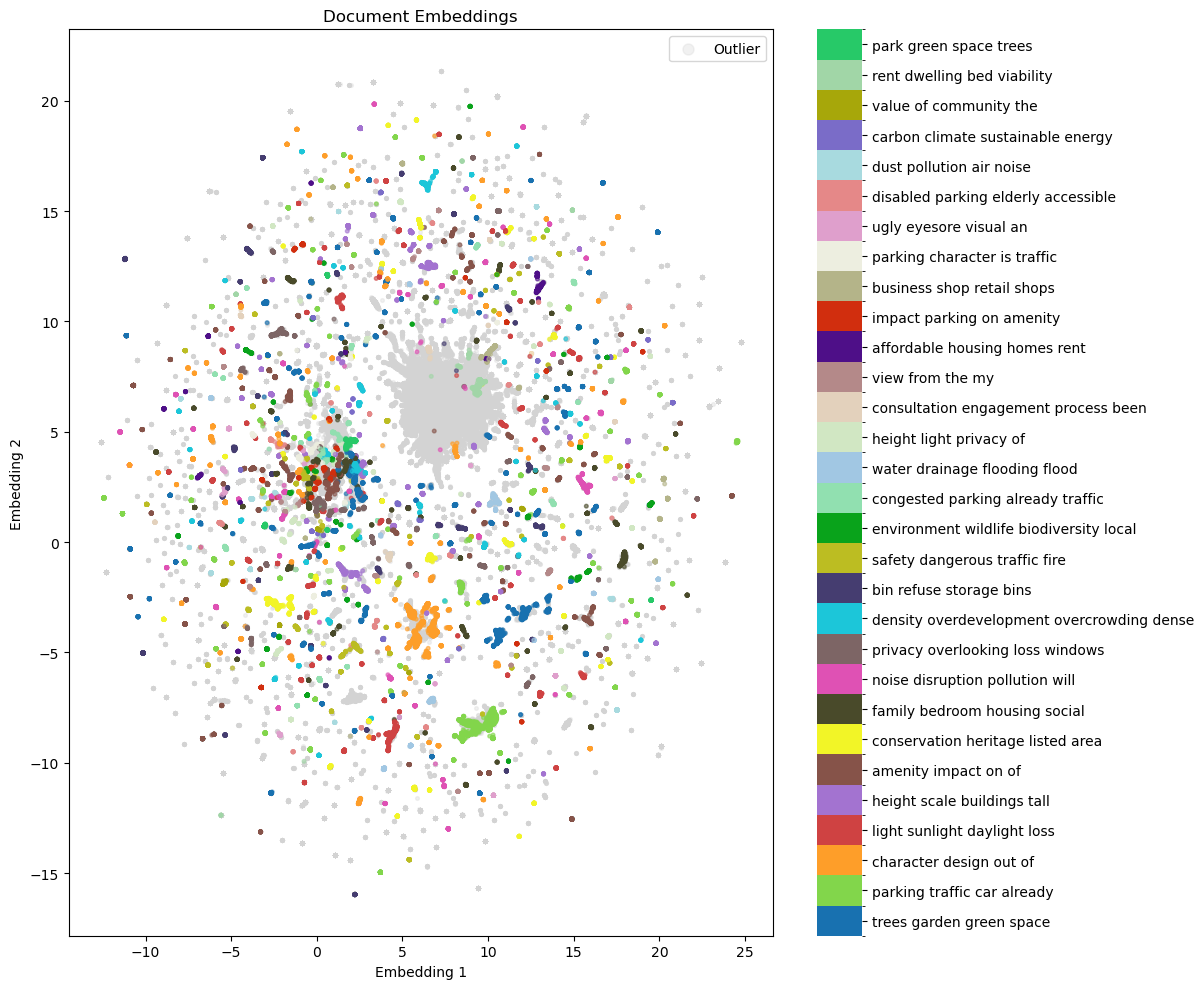

In [43]:
# --- build reduced topic list ---
unique_topics = set()
for topic_list in tp_df['topic_number_updated']:
    unique_topics.update(topic_list)
unique_topics = sorted(unique_topics)

n_topics = len(unique_topics)

print(f'Number of unique topics to plot: {n_topics}')

# --- color palette ---
colors_for_topics = [custom_hex_colors[i % len(custom_hex_colors)] for i in range(n_topics)]
cmap = ListedColormap(colors_for_topics)
norm = BoundaryNorm(boundaries=np.arange(-0.5, n_topics + 0.5, 1), ncolors=n_topics)

# --- figure and axis ---
fig, ax = plt.subplots(figsize=(12, 10))

# ensure boolean masks are proper boolean NumPy arrays
is_outlier = (topics == -1)
is_reduced_topic = np.array([t in unique_topics for t in topics], dtype=bool)

# --- Plot outliers (gray) ---
ax.scatter(
    reduced_embeddings[is_outlier, 0],
    reduced_embeddings[is_outlier, 1],
    color='lightgrey',
    s=7,
    alpha=0.3,
    label='Outlier'
)

# --- Plot other topics (not in reduced list) in gray ---
ax.scatter(
    reduced_embeddings[~is_outlier & ~is_reduced_topic, 0],
    reduced_embeddings[~is_outlier & ~is_reduced_topic, 1],
    color='lightgray',
    s=7,
    alpha=0.3
)

# --- Plot points in your reduced topic list (colored) ---
ax.scatter(
    reduced_embeddings[~is_outlier & is_reduced_topic, 0],
    reduced_embeddings[~is_outlier & is_reduced_topic, 1],
    c=[unique_topics.index(t) for t in topics[~is_outlier & is_reduced_topic]],
    cmap=cmap,
    norm=norm,
    s=7,
    alpha=0.6
)



# --- Labels and layout ---
ax.set_title('Document Embeddings')
ax.set_xlabel('Embedding 1')
ax.set_ylabel('Embedding 2')

# --- Discrete colorbar for selected topics only ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(n_topics))
cbar.ax.set_yticklabels([filtered_topic_dict.get(t, f'Topic {t}') for t in unique_topics])
cbar.outline.set_visible(False)

ax.legend(markerscale=3)
plt.tight_layout()

plt.savefig('../figures/object_topics_scatter.png', dpi=500)
plt.show()